In [12]:
# Import the required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
data = sns.load_dataset('iris')

In [14]:
df = pd.DataFrame(data)
df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [15]:
data.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [16]:
x = df.drop('species',axis=1)
y = df['species']

In [20]:
print(x)
print(y)
print(x.shape)
print(y.shape)

     sepal_length  sepal_width  petal_length  petal_width
0             5.1          3.5           1.4          0.2
1             4.9          3.0           1.4          0.2
2             4.7          3.2           1.3          0.2
3             4.6          3.1           1.5          0.2
4             5.0          3.6           1.4          0.2
..            ...          ...           ...          ...
145           6.7          3.0           5.2          2.3
146           6.3          2.5           5.0          1.9
147           6.5          3.0           5.2          2.0
148           6.2          3.4           5.4          2.3
149           5.9          3.0           5.1          1.8

[150 rows x 4 columns]
0         setosa
1         setosa
2         setosa
3         setosa
4         setosa
         ...    
145    virginica
146    virginica
147    virginica
148    virginica
149    virginica
Name: species, Length: 150, dtype: str
(150, 4)
(150,)


In [23]:
from sklearn.model_selection import train_test_split 

x_train , x_test , y_train , y_test = train_test_split(x,y,random_state=42,test_size=0.3)

In [24]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(105, 4)
(45, 4)
(105,)
(45,)


In [25]:
from sklearn.naive_bayes import GaussianNB

model = GaussianNB()
model.fit(x_train,y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [26]:
y_pred = model.predict(x_test)
model.score(x_test,y_test)

0.9777777777777777

In [27]:
from sklearn.metrics import accuracy_score , confusion_matrix , ConfusionMatrixDisplay
print(accuracy_score(y_test,y_pred))

0.9777777777777777


In [31]:
cmat = confusion_matrix(y_test,y_pred)
print(cmat)

[[19  0  0]
 [ 0 12  1]
 [ 0  0 13]]


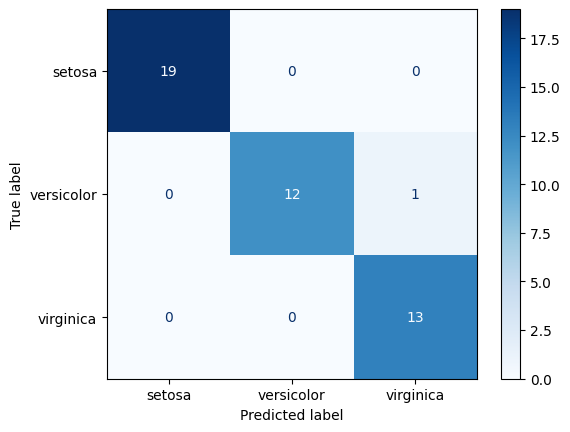

In [30]:
cmartdisplay = ConfusionMatrixDisplay.from_estimator(
            model,
            x_test,
            y_test,
            cmap='Blues'
)
plt.show()

In [34]:
sp = {
    'virginica':2,
    'versicolor':1,
    'setosa':0
}
def get_metrics_cmat(cmt,species):
    indx = sp[species]
    tp = cmt[indx,indx]
    fn = cmt[indx,:].sum() - tp
    fp = cmt[:,indx].sum() - tp
    tn = cmt.sum() - (tp+fn+fp)

    return tp,fn,fp,tn

TP,FN,FP,TN = get_metrics_cmat(cmat,'setosa')
print("TP: ", TP)
print("FP: ", FP)
print("FN: ", FN)
print("TN: ", TN)

TP:  19
FP:  0
FN:  0
TN:  26


In [36]:
print(TP/(FP+TP))
print((TP+TN)/(FP+TP+FN+TN))
print(TP/(TP+FN))

1.0
1.0
1.0
